In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Загрузка данных
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data"
columns = ["Id", "RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"]
df = pd.read_csv(data_url, names=columns, index_col="Id")

# Предварительная обработка
X = df.drop(columns=["Type"])
y = df["Type"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

Logistic Regression (LogisticRegression)

Логистическая регрессия — это линейный классификатор, который используется для бинарных задач классификации. Она моделирует вероятность принадлежности объекта к положительному классу

Support Vector Machine (SVM)

SVM — это алгоритм машинного обучения, используемый для классификации и регрессии. Основная идея заключается в нахождении оптимальной гиперплоскости, разделяющей классы так, чтобы максимизировать отступ (margin) между классами.

K-Nearest Neighbors (k-NN)

Метод k-ближайших соседей — это нелинейный алгоритм классификации, который определяет класс объекта на основе его k ближайших соседей в пространстве признаков. Для классификации используется голосование: объект относится к классу, который чаще встречается среди его соседей.


Random Forest Classifier (RandomForestClassifier)

Случайный лес — это ансамблевая модель, которая строит множество деревьев решений и делает прогноз, усредняя результаты всех деревьев (в случае классификации — через голосование).

Принцип работы:
Строит несколько деревьев решений на случайных подмножествах данных и признаков.
Каждое дерево обучается на случайной выборке данных с повторениями, и на каждом шаге используется случайный набор признаков для разбиений.

Gradient Boosting Classifier (GradientBoostingClassifier)

Градиентный бустинг — это метод ансамблевого обучения, который строит модель, улучшая ошибку предыдущих моделей с помощью градиентного спуска. Модели строятся последовательно, каждая новая модель исправляет ошибки предыдущей.


Оценка моделей

Обучение моделей без подбора гиперпараметров

In [ ]:
# Обучение моделей без подбора гиперпараметров
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "SVM": SVC(),
    "K-NN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)

Logistic Regression Accuracy: 0.7442
              precision    recall  f1-score   support

           1       0.71      0.71      0.71        14
           2       0.69      0.73      0.71        15
           3       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.74        43
   macro avg       0.68      0.74      0.70        43
weighted avg       0.71      0.74      0.73        43

[[10  4  0  0  0  0]
 [ 2 11  1  0  1  0]
 [ 2  1  0  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  0  0  6]]
--------------------------------------------------
SVM Accuracy: 0.7209
              precision    recall  f1-score   support

           1       0.69      0.79      0.73        14
           2       0.69      0.73      0.71        15
           3       0.00      0.00      0.00         3
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

Random Forest Accuracy: 0.8605
              precision    recall  f1-score   support

           1       0.81      0.93      0.87        14
           2       0.86      0.80      0.83        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.86        43
   macro avg       0.89      0.84      0.85        43
weighted avg       0.87      0.86      0.86        43

[[13  1  0  0  0  0]
 [ 2 12  0  0  1  0]
 [ 1  0  2  0  0  0]
 [ 0  1  0  2  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  0  0  6]]
--------------------------------------------------
Gradient Boosting Accuracy: 0.7442
              precision    recall  f1-score   support

           1       0.75      0.64      0.69        14
           2       0.73      0.73      0.73        15
           3       0.67      0.67      0.67       

Корреляционная матрица

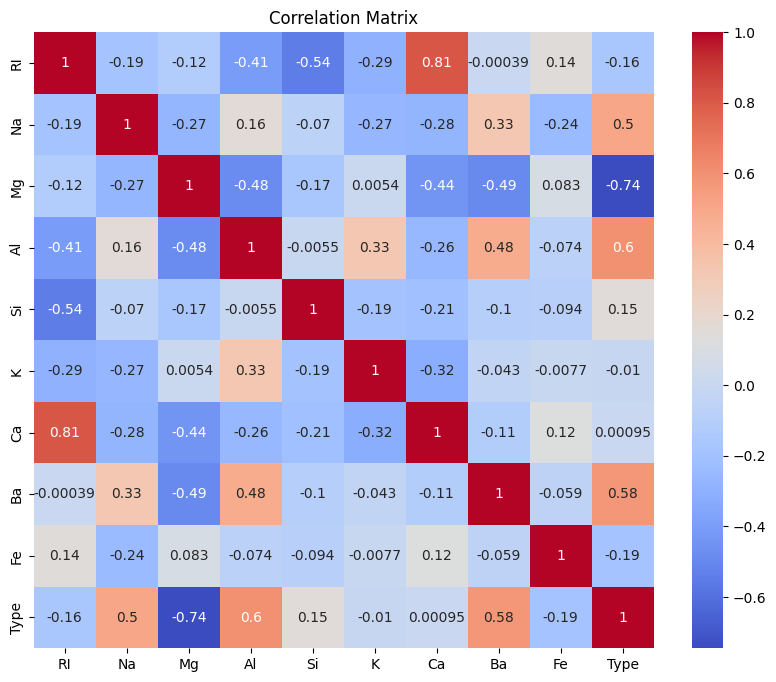

In [ ]:
# Корреляционная матрица
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Подбор гиперпараметров и обучение моделей

In [ ]:
from sklearn.model_selection import GridSearchCV

# Подбор гиперпараметров и обучение моделей
models = {
    "Logistic Regression": (LogisticRegression(max_iter=500), {"C": [0.01, 0.1, 1, 10, 100]}),
    "SVM": (SVC(), {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}),
    "K-NN": (KNeighborsClassifier(), {"n_neighbors": [3, 5, 7, 9]}),
    "Random Forest": (RandomForestClassifier(), {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20]}),
    "Gradient Boosting": (GradientBoostingClassifier(), {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1, 0.2]})
}

best_models = {}
for name, (model, param_grid) in models.items():
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring="accuracy")
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Лучшие параметры для {name}: {grid_search.best_params_}")
    print(f"Лучшая точность: {grid_search.best_score_:.4f}")

Лучшие параметры для Logistic Regression: {'C': 10}
Лучшая точность: 0.6139
Лучшие параметры для SVM: {'C': 10, 'kernel': 'rbf'}
Лучшая точность: 0.6787
Лучшие параметры для K-NN: {'n_neighbors': 7}
Лучшая точность: 0.6439
Лучшие параметры для Random Forest: {'max_depth': 10, 'n_estimators': 200}
Лучшая точность: 0.8017
Лучшие параметры для Gradient Boosting: {'learning_rate': 0.1, 'n_estimators': 200}
Лучшая точность: 0.7143


In [ ]:
# Оценка лучших моделей
results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)

Logistic Regression Accuracy: 0.6512
              precision    recall  f1-score   support

           1       0.69      0.64      0.67        14
           2       0.59      0.67      0.62        15
           3       0.00      0.00      0.00         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       0.83      0.83      0.83         6

    accuracy                           0.65        43
   macro avg       0.63      0.63      0.62        43
weighted avg       0.65      0.65      0.64        43

[[ 9  4  1  0  0  0]
 [ 2 10  1  0  1  1]
 [ 2  1  0  0  0  0]
 [ 0  1  0  2  0  0]
 [ 0  0  0  0  2  0]
 [ 0  1  0  0  0  5]]
--------------------------------------------------
SVM Accuracy: 0.7209
              precision    recall  f1-score   support

           1       0.67      0.71      0.69        14
           2       0.71      0.67      0.69        15
           3       0.50      0.33      0.40         3
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Важность параметров

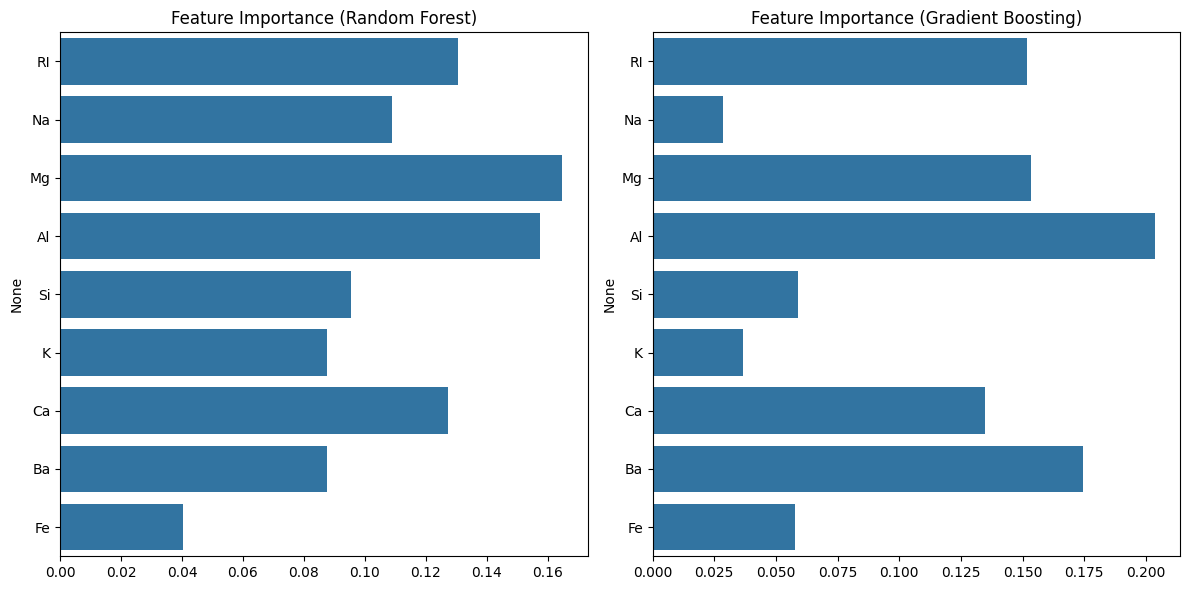

In [ ]:
# Визуализация важности признаков для Random Forest и Gradient Boosting
plt.figure(figsize=(12, 6))

# Random Forest
plt.subplot(1, 2, 1)
rf_model = best_models["Random Forest"]
sns.barplot(x=rf_model.feature_importances_, y=X.columns)
plt.title("Feature Importance (Random Forest)")

# Gradient Boosting
plt.subplot(1, 2, 2)
gb_model = best_models["Gradient Boosting"]
sns.barplot(x=gb_model.feature_importances_, y=X.columns)
plt.title("Feature Importance (Gradient Boosting)")

plt.tight_layout()
plt.show()